In [6]:

 
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

class KMeans:
    def __init__(self, n_clusters=2, max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self, x):
        # Step 1: Initialize centroids randomly
        random_index = random.sample(range(0, x.shape[0]), self.n_clusters)
        self.centroids = x[random_index]

        # Step 2: Repeat until convergence or max iterations
        for i in range(self.max_iter):
            cluster_group = self.assign_cluster(x)
            old_centroids = self.centroids.copy()
            self.centroids = self.move_centroids(x, cluster_group)
            if np.all(old_centroids == self.centroids):
                print(f"Converged after {i+1} iterations.")
                break

        return cluster_group

    def assign_cluster(self, x):
        cluster_group = []
        for row in x:
            distances = [np.sqrt(np.dot(row - centroid, row - centroid)) for centroid in self.centroids]
            min_index = np.argmin(distances)
            cluster_group.append(min_index)
        return np.array(cluster_group)

    def move_centroids(self, x, cluster_group):
        new_centroids = []
        for cluster_id in range(self.n_clusters):         
            cluster_points = x[cluster_group == cluster_id]
            new_centroids.append(cluster_points.mean(axis=0))
        return np.array(new_centroids)

                 
             

 
        
        
        
        
        




Converged after 2 iterations.


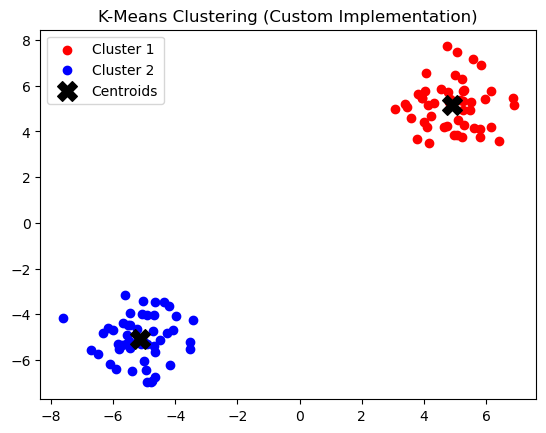

In [8]:
# Generate sample data
centroids = [(-5, -5), (5, 5)]
cluster_std = [1, 1]

X, y = make_blobs(
    n_samples=100,
    cluster_std=cluster_std,
    centers=centroids,
    n_features=2,
    random_state=42
)

# Fit KMeans
km = KMeans(n_clusters=2, max_iter=100)
y_means = km.fit_predict(X)

# Plot clusters
plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1], color='red', label='Cluster 1')
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1], color='blue', label='Cluster 2')

# Plot centroids
plt.scatter(km.centroids[:, 0], km.centroids[:, 1], color='black', marker='X', s=200, label='Centroids')

plt.legend()
plt.title("K-Means Clustering (Custom Implementation)")
plt.show()

